In [33]:
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import os
import random
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import librosa

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision.models import resnet18, ResNet18_Weights
from torchmetrics.classification import MulticlassF1Score

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('sound-of-nature-aicc-round-3')

print("Path to competition files:", path)

100%|██████████| 111M/111M [00:12<00:00, 9.60MB/s] 

Extracting files...


Path to competition files: C:\Users\raian\.cache\kagglehub\competitions\sound-of-nature-aicc-round-3


In [7]:
train_df = pd.read_csv(os.path.join(path, "train.csv"))
test_df = pd.read_csv(os.path.join(path, "test.csv"))

le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["class"])
num_classes = len(le.classes_)

train_df, val_df = train_test_split(train_df, test_size=0.2)

In [73]:
import torchaudio.transforms as T

spec_aug = torch.nn.Sequential(
    T.FrequencyMasking(freq_mask_param=20),
    T.TimeMasking(time_mask_param=40),
)

class AudioDataset(Dataset):
    def __init__(self, df, audio_dir, sr=16000, length=5, augment=None):
        self.df = df
        self.audio_dir = audio_dir
        self.sr = sr
        self.target_len = sr * length
        self.augment = augment

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        y, sr = librosa.load(os.path.join(self.audio_dir, f"{row['sampleID']}.wav"))

        mel = librosa.feature.melspectrogram(y=y, sr=sr)

        mel = torch.from_numpy(mel).float()
        if self.augment is not None:
            mel = self.augment(mel)

        ret = {"mel": mel.unsqueeze(0), "sample_id": row["sampleID"]}
        if "label" in row:
            ret["label"] = row["label"]
        return ret

    def __len__(self):
        return len(self.df)

In [74]:
BATCH_SIZE = 8
train_ds = AudioDataset(train_df, f"{path}/audio", augment=spec_aug)
val_ds = AudioDataset(val_df, f"{path}/audio")

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, BATCH_SIZE)

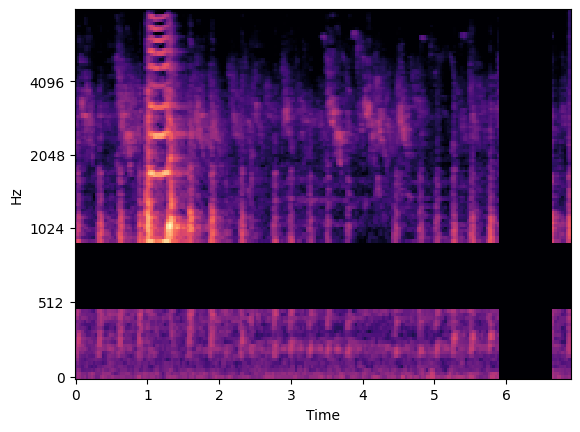

In [79]:
batch = next(iter(train_loader))
{k:batch[k].shape for k in ["mel", "label"]}

sample_idx = 1
sample = batch["mel"][sample_idx][0]

librosa.display.specshow(librosa.power_to_db(sample, ref=np.max), sr=16000,
						x_axis="time", y_axis="mel", cmap="magma")

In [80]:
device = 'cuda'

class AudioResNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = resnet18(weights=ResNet18_Weights.DEFAULT)
        
        self.model.conv1 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)


model = AudioResNet(num_classes).to(device)

In [81]:
import torchinfo
torchinfo.summary(model, input_size=[8,1,128,216])

Layer (type:depth-idx)                        Output Shape              Param #
AudioResNet                                   [8, 9]                    --
├─ResNet: 1-1                                 [8, 9]                    --
│    └─Conv2d: 2-1                            [8, 64, 64, 108]          3,136
│    └─BatchNorm2d: 2-2                       [8, 64, 64, 108]          128
│    └─ReLU: 2-3                              [8, 64, 64, 108]          --
│    └─MaxPool2d: 2-4                         [8, 64, 32, 54]           --
│    └─Sequential: 2-5                        [8, 64, 32, 54]           --
│    │    └─BasicBlock: 3-1                   [8, 64, 32, 54]           73,984
│    │    └─BasicBlock: 3-2                   [8, 64, 32, 54]           73,984
│    └─Sequential: 2-6                        [8, 128, 16, 27]          --
│    │    └─BasicBlock: 3-3                   [8, 128, 16, 27]          230,144
│    │    └─BasicBlock: 3-4                   [8, 128, 16, 27]          295,42

In [82]:
epochs = 5
lr = 3e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()
f1_metric = MulticlassF1Score(num_classes=num_classes, average="macro").to(device)

best_f1 = 0.0

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        mel, label = batch["mel"].to(device), batch["label"].to(device)

        optimizer.zero_grad()
        output = model(mel)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            mel, label = batch["mel"].to(device), batch["label"].to(device)
            output = model(mel)
            f1_metric.update(output, label)

    val_f1 = f1_metric.compute().item()
    f1_metric.reset()

    print(f"Loss: {train_loss/len(train_loader):.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "best_model.pth")

Epoch 1/5: 100%|██████████| 29/29 [00:03<00:00,  7.89it/s]


Loss: 1.9550 | Val F1: 0.3108


Epoch 2/5: 100%|██████████| 29/29 [00:04<00:00,  7.20it/s]


Loss: 1.6343 | Val F1: 0.4014


Epoch 3/5: 100%|██████████| 29/29 [00:03<00:00,  9.05it/s]


Loss: 1.2508 | Val F1: 0.3786


Epoch 4/5: 100%|██████████| 29/29 [00:03<00:00,  8.12it/s]


Loss: 1.0474 | Val F1: 0.5101


Epoch 5/5: 100%|██████████| 29/29 [00:08<00:00,  3.54it/s]


Loss: 0.8022 | Val F1: 0.4738
